# Plate artifacts and corrections

Plates drift, well position matters, and cell count affects most features. This page looks for those artifacts
on a real screen, `pki`: eight plates of kinase inhibitors from the JUMP pilot {cite:p}`Chandrasekaran_2023`. It
removes them and measures whether removing them helped.

Every correction here can make results worse on a given dataset. The last section shows a real case where
sphering, a standard step of the pipeline, cuts mechanism retrieval by more than three quarters.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt
from mantispy._core.plate import well_col, well_row

wells = mt.ds.pki()
mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(wells, na_cutoff=0.0)
wells = mt.pp.subset_features(wells)
wells

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_88405/1239684975.py:12: UserWarning: 133 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")


AnnData object with n_obs × n_vars = 3072 × 850
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy'
    layers: None (.X)

## Position effects

Edge wells evaporate, corners sit at a different temperature, and dispensing drifts along a row.
`pl.plate_effects` shows the row and column medians of each plate. A position artifact appears as a trend across
rows or columns, while noise scatters around the plate median. Two of the eight plates:

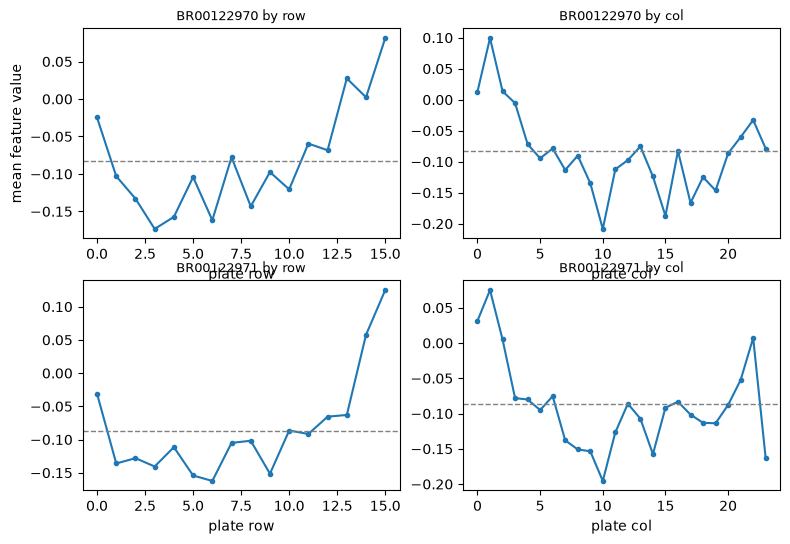

In [2]:
two = wells[wells.obs["Metadata_Plate"].isin(wells.obs["Metadata_Plate"].cat.categories[:2]).to_numpy()].copy()
mt.pl.plate_effects(two)
plt.show()

`correct_plate_position` fits Tukey's median polish to the row and column effects of each plate and subtracts
them. Median polish is used instead of a mean-based fit so that a few extreme wells do not define the gradient.
How much position explains, before and after, as each feature's correlation with the row and the column it sits
in:

In [3]:
rows = np.array([well_row(well) for well in wells.obs["Metadata_Well"]])
columns = np.array([well_col(well) for well in wells.obs["Metadata_Well"]])


def position(adata):
    """Median and largest absolute correlation of a feature with its well's row and column."""
    values = np.asarray(adata.X, dtype=float)
    result = {}
    for name, axis in (("row", rows), ("column", columns)):
        r = np.abs([np.corrcoef(axis, values[:, j])[0, 1] for j in range(values.shape[1])])
        result[f"{name}: median |r|"] = round(float(np.nanmedian(r)), 3)
        result[f"{name}: largest |r|"] = round(float(np.nanmax(r)), 3)
    return result


corrected = mt.pp.correct_plate_position(wells, copy=True)
pd.DataFrame({"before": position(wells), "after": position(corrected)})

,before,after
row: median |r|,0.055,0.012
row: largest |r|,0.316,0.132
column: median |r|,0.070,0.021
column: largest |r|,0.692,0.131


Position explains little of most features and a lot of a few. Before correction the median feature correlates with
its well's column at 0.07, and the most affected one at 0.69; median polish takes the largest correlation with the
row or the column to about 0.13.

If treatments are laid out by column, fit the effects on the controls only, with
`reference="negcon"`, so that treatment effects are not absorbed into a column effect and
subtracted.

This has a limit. A median polish can only fit a column effect for columns that contain
reference rows, and most layouts put the controls in a few fixed columns, such as 1 and 2 or
23 and 24. With controls in four of twenty-four columns there is no control-only column effect
to fit. Row effects still work, because controls in an edge column span every row. For column
effects on a column-wise layout, the design has confounded the effect you want to correct, and
the fix is a randomized layout on the next plate.

## Confounders

Cell count is the most common one: a sparse well looks different from a confluent one regardless of treatment.
`regress_out` fits each feature against the confounder within each plate and keeps the residual.

The fit has to be made on wells whose density varies for technical reasons only. In a compound screen the
treatments change density too, and a compound that thins its wells usually has a phenotype of its own, so a fit
over every well mistakes that phenotype for a density effect. `reference="negcon"` fits on the DMSO wells, keeps
them where normalization centred them, and corrects a well sparser or denser than any control as if it sat at the
edge of their range rather than by extrapolating.

In [4]:
counts = wells.obs["Metadata_CellCount"].to_numpy(dtype=float)
plates = wells.obs["Metadata_Plate"].astype(str).to_numpy()
control = wells.obs["Metadata_Control"].to_numpy(dtype=bool)


def density(adata):
    """How much of each feature follows the cell count, and whether the controls stay centred."""
    values = np.asarray(adata.X, dtype=float)
    within = []
    for plate in np.unique(plates):
        rows = (plates == plate) & control
        r = [np.corrcoef(counts[rows], values[rows, j])[0, 1] for j in range(values.shape[1])]
        within.append(np.nanmedian(np.abs(r)))
    every = [np.corrcoef(counts, values[:, j])[0, 1] for j in range(values.shape[1])]
    return {
        "DMSO wells, within plates: median |r|": round(float(np.median(within)), 3),
        "every well: median |r|": round(float(np.nanmedian(np.abs(every))), 3),
        "DMSO wells off centre": round(float(np.median(np.abs(np.median(values[control], axis=0)))), 3),
    }


print(
    "median cells per well, by plate:",
    wells.obs.groupby("Metadata_Plate", observed=True)["Metadata_CellCount"].median().to_dict(),
)

fit_on_everything = mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate", copy=True)
fit_on_controls = mt.pp.regress_out(
    wells, keys=("Metadata_CellCount",), by="Metadata_Plate", reference="negcon", copy=True
)
pd.DataFrame(
    {
        "before": density(wells),
        "fit on every well": density(fit_on_everything),
        "fit on the DMSO wells": density(fit_on_controls),
    }
)

median cells per well, by plate: {'BR00122970': 1974.5, 'BR00122971': 1956.0, 'BR00122972': 607.5, 'BR00122973': 602.5, 'BR00122974': 1640.0, 'BR00122975': 1631.0, 'BR00122977': 1820.0, 'BR00122978': 1803.5}


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_88405/2231583423.py:27: UserWarning: regress_out: the pooled mean of ['Metadata_CellCount'] lies outside the range Metadata_Plate=['BR00122972', 'BR00122973'] span, so those groups are corrected by extrapolating their own fit, which can leave the result more dependent on the covariate than it was. Pass reference='negcon' to anchor each group at its own controls.
  fit_on_everything = mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate", copy=True)


,before,fit on every well,fit on the DMSO wells
"DMSO wells, within plates: median |r|",0.179,0.193,0.000
every well: median |r|,0.142,0.546,0.132
DMSO wells off centre,0.000,0.409,0.014


Two of the eight plates hold about a third of the others' cells. Fitted on every well, each plate's fit is
re-expressed at the density of the whole screen, which those two plates never reach, so their correction is an
extrapolation, and `regress_out` warns about it. The result follows the cell count more closely than before across
the screen, 0.55 against 0.14, and the DMSO wells end 0.41 off the centre normalization gave them.

Fitted on the DMSO wells, the correction removes the count's pull on them, zero by construction since the fit was
made on them, and leaves them centred. Across every well the correlation stays about where it was. What remains
there is mostly the treatments' own effect: a compound that thins its wells also changes the cells that are left,
and a correction for technical density should not remove that.

Missing values stay missing. Imputing them for the regression and writing the fitted value
back would make an unmeasured value look like a real measurement.

## Plates as batches

A batch effect moves the controls too. `pl.control_drift` projects the control wells onto components fitted on the
controls alone, so if the controls of different plates land in different places, the reference itself shifts
between them.

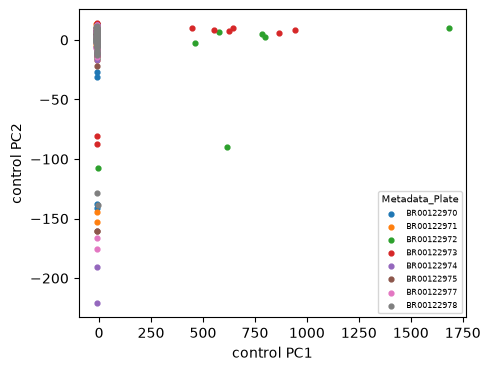

In [5]:
mt.pl.control_drift(wells, groupby="Metadata_Plate")
plt.show()

### Measuring the result

`mt.metrics` scores a representation with several metrics. Batch-mixing metrics and biological-signal metrics
trade off against each other, and a correction that improves one at the expense of the other has not helped.

Normalizing each plate against its own controls is itself a batch correction. Here it is measured against one
normalization pooled over the whole screen, on the same features:

In [6]:
pooled = mt.ds.pki()
mt.pp.normalize(pooled, method="mad_robustize", by=None, reference="negcon")
pooled = pooled[:, wells.var_names].copy()

sc.pp.pca(wells, n_comps=20)
sc.pp.pca(pooled, n_comps=20)
wells.obsm["X_pooled"] = pooled.obsm["X_pca"]

table = mt.metrics.evaluate_correction(
    wells, reps=("X_pooled", "X_pca"), label_key="Metadata_Perturbation", batch_key="Metadata_Plate"
)
table

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_88405/2314355432.py:2: UserWarning: 130 of 5839 features have no spread in at least one group of None among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(pooled, method="mad_robustize", by=None, reference="negcon")


,metric,representation,key,value,better
0,silhouette_label,X_pooled,Metadata_Perturbation,0.468931,higher
1,silhouette_batch,X_pooled,Metadata_Plate,0.871798,higher
2,ilisi,X_pooled,Metadata_Plate,1.810165,higher
3,clisi,X_pooled,Metadata_Perturbation,4.944911,lower
4,pc_regression,X_pooled,Metadata_Plate,0.818234,lower
5,silhouette_label,X_pca,Metadata_Perturbation,0.373248,higher
6,silhouette_batch,X_pca,Metadata_Plate,0.833440,higher
7,ilisi,X_pca,Metadata_Plate,2.572630,higher
8,clisi,X_pca,Metadata_Perturbation,4.465038,lower
9,pc_regression,X_pca,Metadata_Plate,0.025963,lower


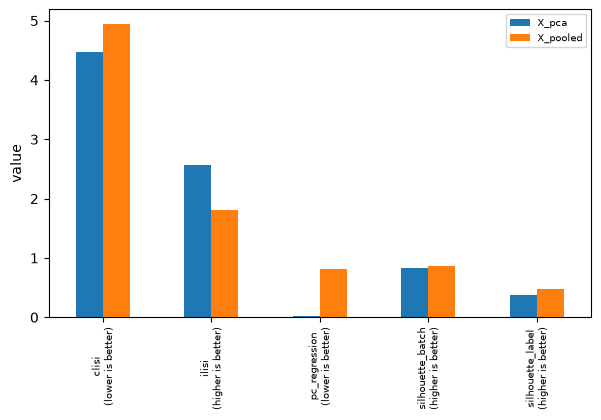

In [7]:
mt.pl.metrics(table)
plt.show()

Check the `better` column: two of the five metrics are better when lower. Per-plate normalization takes the plate's
share of the variance from 82% to 3%, and a well's neighbours come from more plates, an iLISI of 2.6 against 1.8.
The label and batch silhouettes go the other way, 0.37 against 0.47 and 0.83 against 0.87. The metrics trade off, which is why the pages that
follow judge a correction by retrieval, the question a screen asks.

`pl.batch_variance` shows the plate's share per component, which tells you where in the embedding it sits.

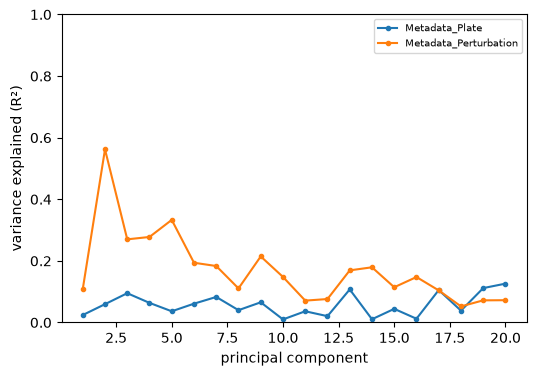

In [8]:
mt.pl.batch_variance(wells, keys=["Metadata_Plate", "Metadata_Perturbation"], use_rep="X_pca")
plt.show()

Harmony, the last step of the JUMP recipe, corrects an embedding rather than the features.
[Reproducing across laboratories](../multisite/cross_laboratory.ipynb) runs it on JUMP and measures the result.
For a correction on the features instead of an embedding, `sc.pp.combat` is the usual choice.

## Sphering, and a correction that makes things worse

Sphering is typical variation normalization. The covariance of the negative controls describes variation that is
not of interest, and whitening removes it, leaving the variation caused by the perturbations. `ZCA-cor` is the
default because it rotates back into the original feature basis, so the columns still match `var`.

Sphering needs more control wells than features. BBBC021 {cite:p}`Ljosa_2013` has few control wells for the
features that survive selection, so its control covariance is singular. Score mechanism retrieval with and
without sphering, with the not-same-compound rule from [Mechanism of action](../compounds/mechanism_of_action.ipynb).

In [9]:
def not_same_compound(adata):
    """Not-same-compound mechanism retrieval on one signature per treatment."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
    signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()
    mt.tl.nn_moa_classify(signatures, scheme="nsc")
    return round(signatures.uns["mantispy"]["moa"]["accuracy"], 3)


bbbc = mt.ds.bbbc021()
mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(bbbc, na_cutoff=0.0)
bbbc = mt.pp.subset_features(bbbc)

sphered = bbbc.copy()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    mt.pp.sphere(sphered, method="ZCA-cor", reference="negcon")
print(caught[0].message)

{
    "control wells": int(bbbc.obs["Metadata_Control"].sum()),
    "features": bbbc.n_vars,
    "without sphering": not_same_compound(bbbc),
    "with sphering": not_same_compound(sphered),
}

sphering is fitted on 330 reference rows for 343 features. With fewer rows than features the covariance is singular and the transform amplifies noise. Select fewer features first, or use more controls.


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_88405/1216217037.py:11: UserWarning: 2 of 467 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'control wells': 330,
 'features': 343,
 'without sphering': 0.777,
 'with sphering': 0.175}

Sphering cuts not-same-compound accuracy from 0.78 to 0.18, a loss of more than three quarters, on 330 control
wells for 343 features. mantispy's sphering is tested against pycytominer's, so pycytominer should show the same
drop.

Measure a correction on the question the screen asks before adopting it. For this dataset, either select fewer
features so the control covariance is well determined, or skip sphering.

Next: [Is the screen any good?](screen_quality.ipynb)